In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
# Q1. Pandas version
pd.__version__

'3.0.6'

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')

In [3]:
df.head(2)

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3


In [4]:
df.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [5]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

model_year
[2006 2008 1996 1989 1994]
50

origin
<StringArray>
['Europe', 'Asia', 'USA']
Length: 3, dtype: str
3

fuel_type
<StringArray>
['Gasoline', 'Diesel', 'Hybrid']
Length: 3, dtype: str
3

drivetrain
<StringArray>
['Front-wheel drive', 'Rear-wheel drive', 'All-wheel drive']
Length: 3, dtype: str
3

num_doors
[4 5 3 2]
4

engine_displacement
[2180 2390 2320 2130 2580]
127

num_cylinders
[6 7 5 8 4]
5

horsepower
[243. 272. 267. 258. 304.]
153

vehicle_weight
[3870 4210 4240 4490 4510]
176

acceleration
[ nan 17.3 18.7 17.5 18.8]
93

fuel_efficiency_mpg
[31.9 31.3 27.5 28.5 31. ]
188



In [6]:
features = ['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']
features
df = df[features]



<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

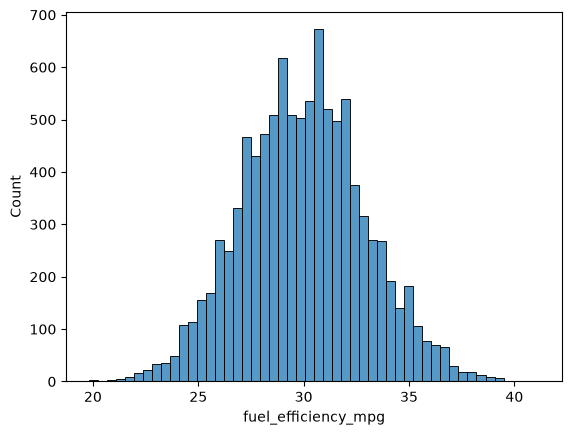

In [7]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

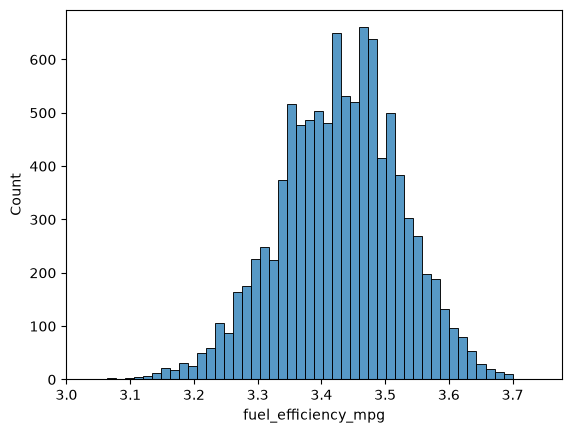

In [8]:
price_logs = np.log1p(df.fuel_efficiency_mpg)
sns.histplot(price_logs, bins=50)

In [9]:
# Question 1: There's one column with missing values. What is it?
df.isnull().sum()


engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [10]:
# Question 2 What's the median (50% percentile) for variable 'horsepower'?
df['horsepower'].median()

np.float64(254.0)

In [11]:
# Question 3: 


In [20]:
# Prepare and split data set 
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]
    
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
n, n_val, n_test, n_train 

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values 

# y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
# y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
# y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
df_train.isnull().sum()

engine_displacement      0
horsepower             538
vehicle_weight           0
model_year               0
dtype: int64

In [21]:
# With fill mising column by 0 
X_train = df_train.fillna(0).values
# print(df_train.isnull().sum(), X_train.isnull().sum())
w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_train.dot(w)

y_pred 

array([34.07471478, 29.24093577, 32.95179055, ..., 29.32203017,
       31.8448482 , 29.69112172], shape=(6000,))

<Axes: ylabel='Count'>

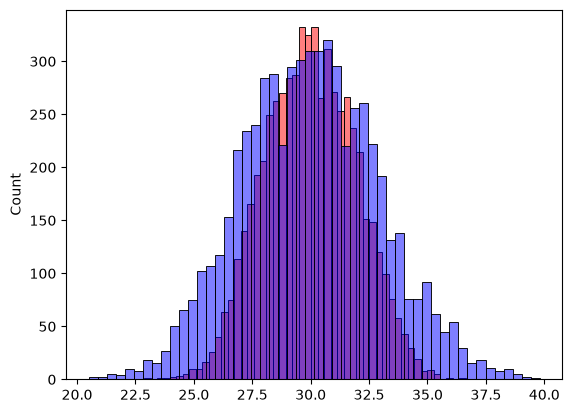

In [22]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

In [23]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    result = round(np.sqrt(mse),3)
    return result

In [24]:
X_val = df_val.fillna(0).values
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(2.205)

In [25]:
# With fill mising column by the mean of training set 

# print(df_train.isnull().sum())
X_train = df_train.copy()

mean = X_train["horsepower"].mean()
X_train["horsepower"] = X_train["horsepower"].fillna(mean)
X_train = X_train.values
# print(df_train.isnull().sum(), X_train.isnull().sum())
w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_train.dot(w)

y_pred 

array([33.9590606 , 29.31436861, 32.76131994, ..., 29.30040609,
       31.92376266, 29.67268373], shape=(6000,))

<Axes: ylabel='Count'>

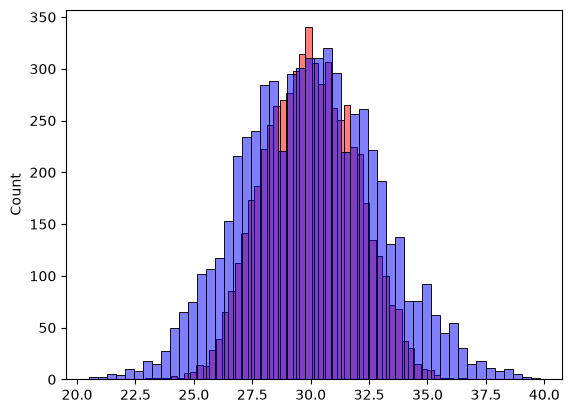

In [26]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

In [27]:
X_val = df_val.fillna(mean).values
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(2.202)

In [38]:
## Question 4
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]
    
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    result = round(np.sqrt(mse),4)
    return result
# With fill mising column by 0 
X_train = df_train.fillna(0).values
X_val = df_val.fillna(0).values
# print(df_train.isnull().sum(), X_train.isnull().sum())

In [42]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    print(r, w0, score)

0 -153.8849618823138 2.2053
0.01 -148.3092124404723 2.2058
0.1 -111.83871039306318 2.2241
1 -32.331865964971264 2.3492
5 -7.7728522099734025 2.4094
10 -3.9871164160193766 2.4195
100 -0.40821964884790385 2.4292


In [47]:
#Q5 
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    result = np.sqrt(mse)
    return result
    
scores = np.array([])

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]: 
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    n, n_val, n_test, n_train 
    
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values 
    
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg'] 
    
    # With fill mising column by 0 
    X_train = df_train.fillna(0).values
    X_val = df_val.fillna(0).values
    # print(df_train.isnull().sum(), X_train.isnull().sum())
    w0, w = train_linear_regression(X_train, y_train)
    
    y_pred = w0 + X_val.dot(w)

    scores = np.append(scores, rmse(y_val, y_pred))

scores
std = np.std(scores)
std = round(std, 3)
std


np.float64(0.029)

In [48]:
# Question 6 
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
n, n_val, n_test, n_train 

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values 

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg'] 

df_full_train = pd.concat([df_train, df_val])
y_full_train = np.concatenate([y_train, y_val])

# With fill mising column by 0 
X_full_train = df_full_train.fillna(0).values
X_test = df_test.fillna(0).values

# print(df_train.isnull().sum(), X_train.isnull().sum())
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(2.235827747191731)